In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import euclidean_distances
import warnings
warnings.filterwarnings('ignore')

# Pull per-game stats from Basketball-Reference
url = "https://www.basketball-reference.com/leagues/NBA_2026_per_game.html"
tables = pd.read_html(url)
df = tables[0]

print(f"Raw data shape: {df.shape}")
df.head()

Raw data shape: (734, 31)


,Rk,Player,Age,Team,Pos,G,GS,MP,FG,FGA,...,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS,Awards
0,1.0,Luka Dončić,26.0,LAL,PG,64.0,64.0,35.8,10.8,22.8,...,0.6,7.1,7.7,8.3,1.6,0.5,4.0,2.4,33.5,"CPOY-8,AS"
1,2.0,Shai Gilgeous-Alexander,27.0,OKC,PG,68.0,68.0,33.2,10.8,19.4,...,0.6,3.7,4.3,6.6,1.4,0.8,2.2,2.0,31.1,"CPOY-1,AS"
2,3.0,Anthony Edwards,24.0,MIN,SG,61.0,60.0,35.0,9.9,20.2,...,0.6,4.4,5.0,3.7,1.4,0.8,2.9,1.9,28.8,"CPOY-3,AS"
3,4.0,Jaylen Brown,29.0,BOS,SF,71.0,71.0,34.4,10.4,21.7,...,1.1,5.8,6.9,5.1,1.0,0.4,3.6,2.7,28.7,AS
4,5.0,Tyrese Maxey,25.0,PHI,PG,70.0,70.0,38.0,9.9,21.4,...,0.3,3.8,4.1,6.6,1.9,0.8,2.4,2.2,28.3,"CPOY-7,AS"


In [53]:
def deduplicate_traded_players(df_input):
    """For traded players, keep only the season-total row (2TM/3TM/4TM)."""
    cleaned_rows = []
    for player, group in df_input.groupby('Player'):
        if len(group) == 1:
            cleaned_rows.append(group)
        else:
            multi_team = group[group['Team'].isin(['2TM', '3TM', '4TM'])]
            if len(multi_team) > 0:
                cleaned_rows.append(multi_team)
            else:
                cleaned_rows.append(group.nlargest(1, 'G'))
    return pd.concat(cleaned_rows, ignore_index=False)

df_dedup = deduplicate_traded_players(df)

print(f"Original rows: {len(df)}")
print(f"After deduplication: {len(df_dedup)}")
print(f"Duplicates remaining: {df_dedup['Player'].duplicated().sum()}")

Original rows: 734
After deduplication: 583
Duplicates remaining: 0


In [54]:
# When a player attempts 0 threes, pandas gives 3P%=1.0 by mistake. Set to 0.
df_dedup['3PA'] = pd.to_numeric(df_dedup['3PA'], errors='coerce')
df_dedup['3P%'] = pd.to_numeric(df_dedup['3P%'], errors='coerce')
df_dedup.loc[df_dedup['3PA'] == 0, '3P%'] = 0

df_dedup['FTA'] = pd.to_numeric(df_dedup['FTA'], errors='coerce')
df_dedup['FT%'] = pd.to_numeric(df_dedup['FT%'], errors='coerce')
df_dedup.loc[df_dedup['FTA'] == 0, 'FT%'] = 0

print("Fixed bad percentage values for non-shooters")

Fixed bad percentage values for non-shooters


In [55]:
# Filter to qualified players
df_dedup['G'] = pd.to_numeric(df_dedup['G'], errors='coerce')
df_dedup['MP'] = pd.to_numeric(df_dedup['MP'], errors='coerce')
df_filtered = df_dedup[(df_dedup['G'] >= 20) & (df_dedup['MP'] >= 15)].copy()
df_filtered = df_filtered[df_filtered['Player'] != 'League Average']

# Convert all stat columns to numeric
stat_cols = ['FGA', '3PA', '3P%', '2PA', 'FT%', 'FTA', 'ORB', 'DRB',
             'AST', 'STL', 'BLK', 'TOV', 'PF', 'PTS', 'eFG%', 'MP']
for col in stat_cols:
    df_filtered[col] = pd.to_numeric(df_filtered[col], errors='coerce')

# Engineer style features (rates and per-36 stats, not raw counts)
df_filtered['3PAr'] = df_filtered['3PA'] / df_filtered['FGA']
df_filtered['FTr'] = df_filtered['FTA'] / df_filtered['FGA']
df_filtered['AST_per36'] = df_filtered['AST'] * 36 / df_filtered['MP']
df_filtered['TRB_per36'] = (df_filtered['ORB'] + df_filtered['DRB']) * 36 / df_filtered['MP']
df_filtered['STL_per36'] = df_filtered['STL'] * 36 / df_filtered['MP']
df_filtered['BLK_per36'] = df_filtered['BLK'] * 36 / df_filtered['MP']
df_filtered['ORB_per36'] = df_filtered['ORB'] * 36 / df_filtered['MP']
df_filtered['PTS_per36'] = df_filtered['PTS'] * 36 / df_filtered['MP']

# Define which features we'll cluster on
features = ['3PAr', 'FTr', '3P%', 'eFG%', 'FT%',
            'AST_per36', 'TRB_per36', 'ORB_per36',
            'STL_per36', 'BLK_per36', 'PTS_per36']

df_clean = df_filtered.dropna(subset=features).copy()

print(f"Final dataset: {len(df_clean)} players, {len(features)} features")
df_clean[['Player', 'Team', 'Pos'] + features].head(10)

Final dataset: 350 players, 11 features


,Player,Team,Pos,3PAr,FTr,3P%,eFG%,FT%,AST_per36,TRB_per36,ORB_per36,STL_per36,BLK_per36,PTS_per36
236,A.J. Green,MIL,SG,0.898734,0.101266,0.419,0.612,0.855,2.350515,3.463918,0.494845,0.618557,0.123711,12.865979
103,Aaron Gordon,DEN,PF,0.396396,0.405405,0.389,0.574,0.767,3.483871,7.483871,1.806452,0.774194,0.387097,20.903226
146,Aaron Nesmith,IND,SF,0.543860,0.219298,0.379,0.517,0.829,2.303030,5.090909,1.333333,0.727273,0.606061,16.727273
270,Aaron Wiggins,OKC,SG,0.512195,0.134146,0.356,0.521,0.736,2.807339,4.954128,0.990826,1.486239,0.660550,15.522936
145,Ace Bailey,UTA,SF,0.443548,0.096774,0.344,0.520,0.750,2.347826,5.478261,1.826087,1.043478,0.913043,18.000000
507,Adem Bona,PHI,C,0.032258,0.516129,0.333,0.600,0.708,1.034483,8.896552,3.724138,0.827586,2.482759,9.931034
156,Ajay Mitchell,OKC,SG,0.298077,0.269231,0.347,0.536,0.870,5.023256,4.604651,0.976744,1.674419,0.418605,18.976744
322,Al Horford,GSW,C,0.638889,0.083333,0.361,0.540,0.846,4.353488,8.204651,1.674419,1.172093,1.841860,13.897674
433,Alex Caruso,OKC,SG,0.592593,0.166667,0.293,0.512,0.804,3.956044,5.538462,0.989011,2.571429,0.593407,12.263736
101,Alex Sarr,WAS,C,0.226277,0.218978,0.333,0.520,0.692,3.573529,9.794118,2.911765,1.058824,2.647059,21.573529


In [56]:
X = df_clean[features].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Shape: {X_scaled.shape}")
print(f"Mean of each feature (should be ~0): {X_scaled.mean(axis=0).round(2)}")
print(f"Std of each feature (should be ~1): {X_scaled.std(axis=0).round(2)}")

Shape: (350, 11)
Mean of each feature (should be ~0): [-0.  0.  0.  0.  0. -0.  0. -0.  0. -0. -0.]
Std of each feature (should be ~1): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


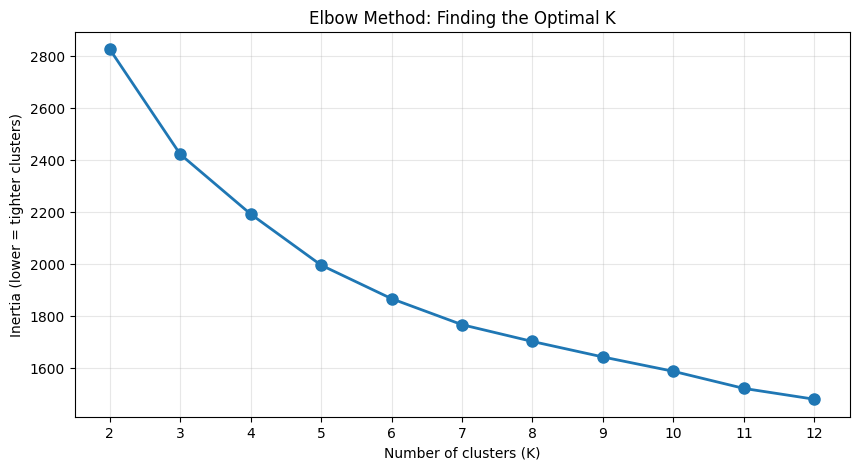

In [57]:
inertias = []
k_range = range(2, 13)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(k_range, inertias, marker='o', linewidth=2, markersize=8)
plt.xlabel('Number of clusters (K)')
plt.ylabel('Inertia (lower = tighter clusters)')
plt.title('Elbow Method: Finding the Optimal K')
plt.grid(True, alpha=0.3)
plt.xticks(k_range)
plt.show()

In [58]:
kmeans = KMeans(n_clusters=6, random_state=42, n_init=10)
df_clean['cluster'] = kmeans.fit_predict(X_scaled)

print("Cluster sizes:")
print(df_clean['cluster'].value_counts().sort_index())
print()
print("Position breakdown per cluster:")
print(pd.crosstab(df_clean['cluster'], df_clean['Pos']))

Cluster sizes:
cluster
0    71
1    91
2    22
3    86
4    56
5    24
Name: count, dtype: int64

Position breakdown per cluster:
Pos       C  PF  PG  SF  SG
cluster                    
0        15  35   0  14   7
1         1  10  14  20  46
2        21   1   0   0   0
3         4  12  29  22  19
4         0   4  21   7  24
5        18   6   0   0   0


In [59]:
cluster_profiles = df_clean.groupby('cluster')[features].mean().round(2)
print("Average stats by cluster:")
cluster_profiles

Average stats by cluster:


,3PAr,FTr,3P%,eFG%,FT%,AST_per36,TRB_per36,ORB_per36,STL_per36,BLK_per36,PTS_per36
cluster,,,,,,,,,,,
0,0.45,0.22,0.36,0.56,0.74,2.66,7.65,2.05,1.19,0.89,15.44
1,0.61,0.17,0.37,0.54,0.82,3.32,4.42,0.93,1.06,0.38,15.20
2,0.01,0.42,0.02,0.66,0.64,2.46,11.69,4.60,1.11,1.52,14.25
3,0.36,0.33,0.35,0.54,0.83,5.69,5.79,1.13,1.20,0.47,22.82
4,0.45,0.21,0.32,0.50,0.75,4.95,5.22,1.29,1.93,0.61,13.76
5,0.20,0.33,0.34,0.58,0.68,3.38,11.58,3.91,1.13,1.72,18.32


In [60]:
for cluster_num in sorted(df_clean['cluster'].unique()):
    print(f"\n{'='*60}")
    print(f"CLUSTER {cluster_num}")
    print(f"{'='*60}")
    cluster_players = df_clean[df_clean['cluster'] == cluster_num].sort_values('MP', ascending=False)
    print(cluster_players[['Player', 'Team', 'Pos', 'MP', 'PTS']].head(10).to_string(index=False))


CLUSTER 0
           Player Team Pos   MP  PTS
 Jabari Smith Jr.  HOU  PF 35.1 15.8
    Keegan Murray  SAC  PF 34.5 14.0
       OG Anunoby  NYK  PF 33.2 16.7
  Christian Braun  DEN  SG 31.8 12.0
  Jaden McDaniels  MIN  PF 31.7 14.8
  Kelly Oubre Jr.  PHI  SF 31.5 14.1
  P.J. Washington  DAL  PF 31.0 14.2
   Onyeka Okongwu  ATL   C 31.0 15.2
   Andrew Wiggins  MIA  SF 30.3 15.4
Jaren Jackson Jr.  2TM   C 30.3 19.4

CLUSTER 1
          Player Team Pos   MP  PTS
   Derrick White  BOS  SG 34.1 16.5
  Toumani Camara  POR  PF 33.3 13.4
   Mikal Bridges  NYK  SF 32.8 14.4
Payton Pritchard  BOS  PG 32.4 17.0
    Kon Knueppel  CHO  SF 31.5 18.5
     Zach LaVine  SAC  SG 31.4 19.2
 Cameron Johnson  DEN  SF 30.5 12.2
   Devin Vassell  SAS  SG 30.5 13.9
Donte DiVincenzo  MIN  SG 30.4 12.2
   Aaron Nesmith  IND  SF 29.7 13.8

CLUSTER 2
            Player Team Pos   MP  PTS
       Rudy Gobert  MIN   C 31.3 10.9
       Ivica Zubac  2TM   C 30.1 14.1
       Jalen Duren  DET   C 28.2 19.5
     Deandre

In [61]:
cluster_names = {
    0: 'Two-Way Forwards',
    1: '3-and-D Wings',
    2: 'Rim-Running Centers',
    3: 'Primary Scorers',
    4: 'Defensive Connectors',
    5: 'Skilled Bigs'
}

df_clean['archetype'] = df_clean['cluster'].map(cluster_names)
print(df_clean['archetype'].value_counts())

archetype
3-and-D Wings           91
Primary Scorers         86
Two-Way Forwards        71
Defensive Connectors    56
Skilled Bigs            24
Rim-Running Centers     22
Name: count, dtype: int64


In [62]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
df_clean['pca_x'] = X_pca[:, 0]
df_clean['pca_y'] = X_pca[:, 1]

print(f"PC1 captures {pca.explained_variance_ratio_[0]*100:.1f}% of variance")
print(f"PC2 captures {pca.explained_variance_ratio_[1]*100:.1f}% of variance")
print(f"Total: {sum(pca.explained_variance_ratio_)*100:.1f}%")

PC1 captures 37.9% of variance
PC2 captures 16.9% of variance
Total: 54.8%


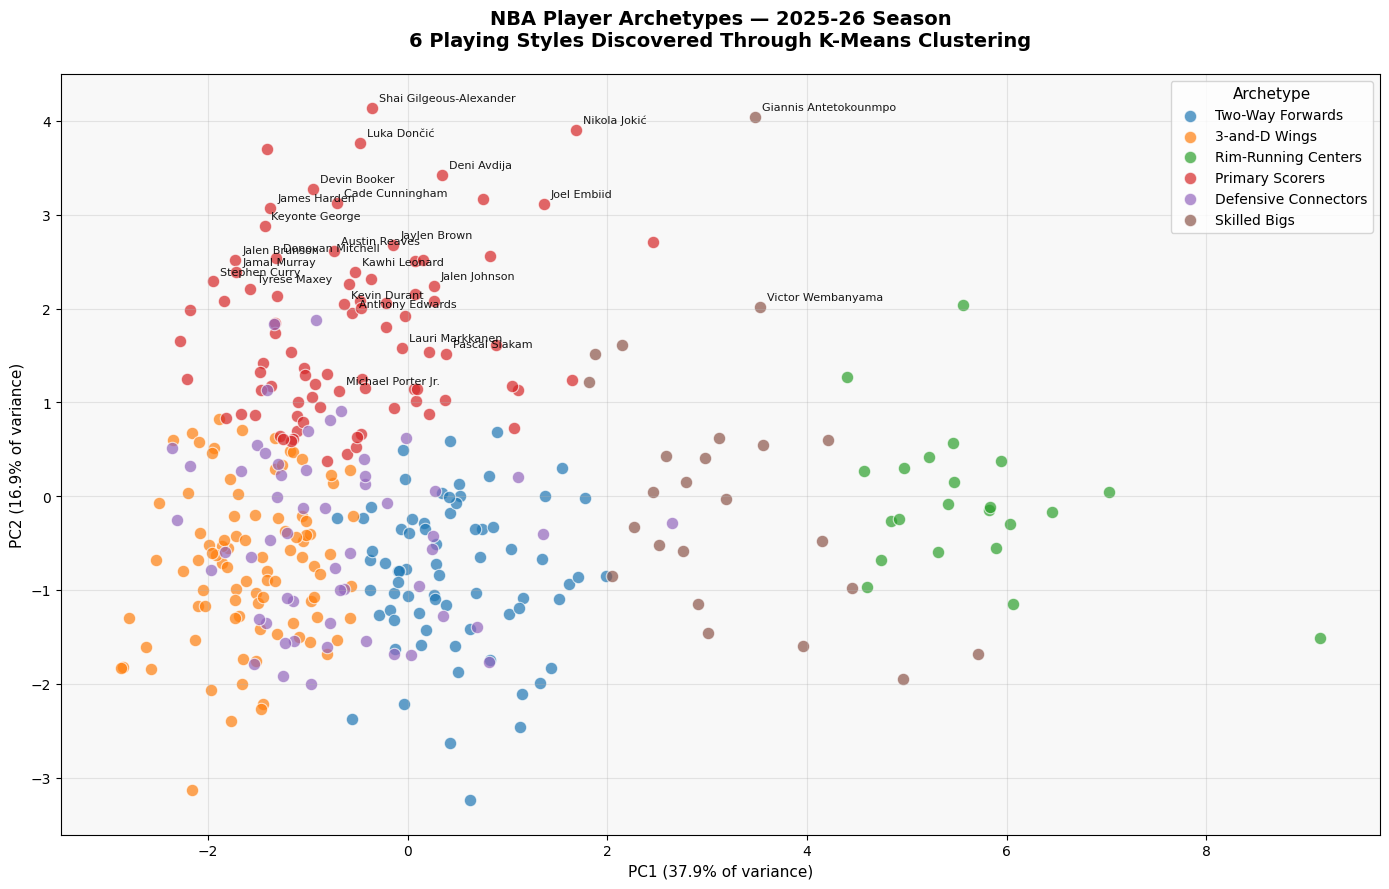

Saved as nba_archetypes.png


In [63]:
fig, ax = plt.subplots(figsize=(14, 9))
palette = sns.color_palette("tab10", n_colors=6)

for i, archetype in enumerate(cluster_names.values()):
    cluster_data = df_clean[df_clean['archetype'] == archetype]
    ax.scatter(cluster_data['pca_x'], cluster_data['pca_y'],
               label=archetype, color=palette[i],
               s=80, alpha=0.7, edgecolor='white', linewidth=0.8)

# Label top 25 scorers
top_players = df_clean.sort_values('PTS', ascending=False).head(25)
for _, row in top_players.iterrows():
    ax.annotate(row['Player'], (row['pca_x'], row['pca_y']),
                fontsize=8, alpha=0.9,
                xytext=(5, 5), textcoords='offset points')

ax.set_title('NBA Player Archetypes — 2025-26 Season\n6 Playing Styles Discovered Through K-Means Clustering',
             fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% of variance)', fontsize=11)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% of variance)', fontsize=11)
ax.legend(title='Archetype', loc='best', fontsize=10, title_fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_facecolor('#f8f8f8')

plt.tight_layout()
plt.savefig('nba_archetypes.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved as nba_archetypes.png")

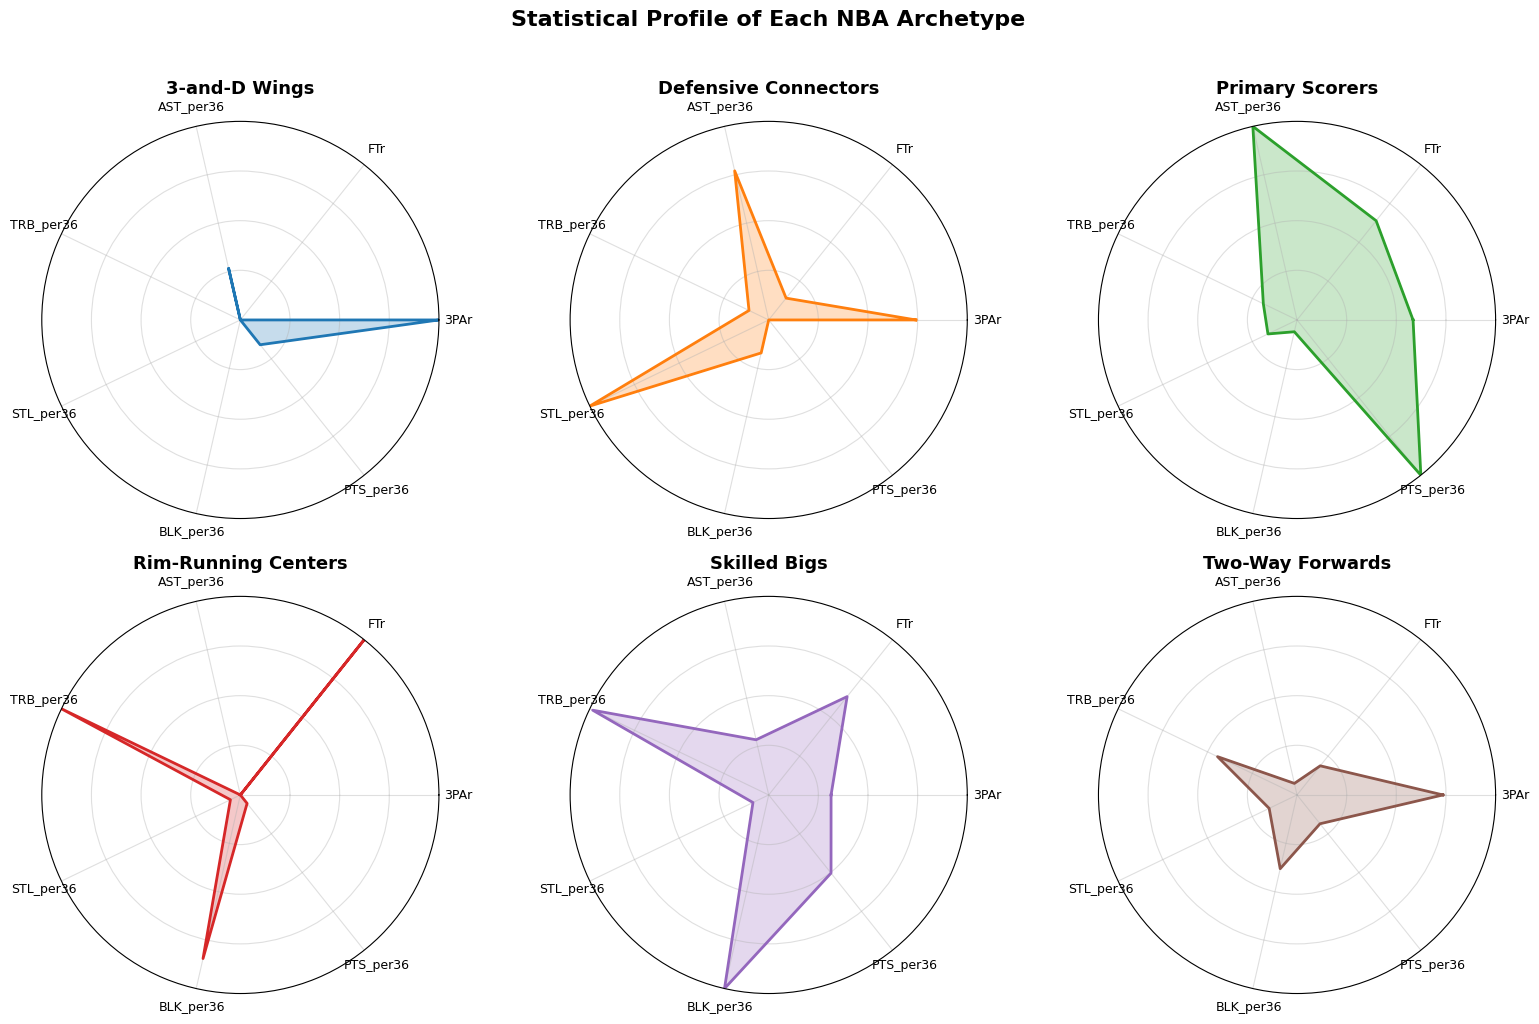

Saved as nba_radars.png


In [64]:
radar_features = ['3PAr', 'FTr', 'AST_per36', 'TRB_per36', 
                  'STL_per36', 'BLK_per36', 'PTS_per36']

radar_data = df_clean.groupby('archetype')[radar_features].mean()
radar_normalized = (radar_data - radar_data.min()) / (radar_data.max() - radar_data.min())

angles = np.linspace(0, 2 * np.pi, len(radar_features), endpoint=False).tolist()
angles += angles[:1]

fig, axes = plt.subplots(2, 3, figsize=(16, 10), subplot_kw=dict(projection='polar'))
axes = axes.flatten()
palette = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

for idx, archetype in enumerate(radar_normalized.index):
    values = radar_normalized.loc[archetype].tolist()
    values += values[:1]
    
    ax = axes[idx]
    ax.plot(angles, values, color=palette[idx], linewidth=2)
    ax.fill(angles, values, color=palette[idx], alpha=0.25)
    
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(radar_features, size=9)
    ax.set_ylim(0, 1)
    ax.set_yticks([0.25, 0.5, 0.75])
    ax.set_yticklabels(['', '', ''], size=7)
    ax.set_title(archetype, size=13, fontweight='bold', pad=20)
    ax.grid(True, alpha=0.4)

plt.suptitle('Statistical Profile of Each NBA Archetype', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('nba_radars.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved as nba_radars.png")

In [65]:
def find_similar_players(player_name, n=5):
    matches = df_clean[df_clean['Player'].str.contains(player_name, case=False, na=False)]
    
    if len(matches) == 0:
        print(f"No player found matching '{player_name}'")
        return
    
    if len(matches) > 1:
        print(f"Multiple matches. Using first: {matches.iloc[0]['Player']}")
    
    player = matches.iloc[0]
    player_idx = matches.index[0]
    
    player_vector = X_scaled[df_clean.index.get_loc(player_idx)].reshape(1, -1)
    distances = euclidean_distances(player_vector, X_scaled)[0]
    
    df_temp = df_clean.copy()
    df_temp['distance'] = distances
    similar = df_temp[df_temp['Player'] != player['Player']].nsmallest(n, 'distance')
    
    print(f"\n{'='*60}")
    print(f"PLAYER: {player['Player']} ({player['Team']}, {player['Pos']})")
    print(f"ARCHETYPE: {player['archetype']}")
    print(f"{'='*60}")
    print(f"\n{n} Most Stylistically Similar Players:\n")
    print(similar[['Player', 'Team', 'Pos', 'archetype', 'PTS']].to_string(index=False))

# Try it
find_similar_players('Luka')
find_similar_players('Duncan')
find_similar_players('Curry')
find_similar_players('Wembanyama')

Multiple matches. Using first: Luka Dončić

PLAYER: Luka Dončić (LAL, PG)
ARCHETYPE: Primary Scorers

5 Most Stylistically Similar Players:

                 Player Team Pos       archetype  PTS
Shai Gilgeous-Alexander  OKC  PG Primary Scorers 31.1
       Donovan Mitchell  CLE  SG Primary Scorers 27.9
           Jaylen Brown  BOS  SF Primary Scorers 28.7
           James Harden  2TM  PG Primary Scorers 23.6
        Cade Cunningham  DET  PG Primary Scorers 23.9

PLAYER: Duncan Robinson (DET, SF)
ARCHETYPE: 3-and-D Wings

5 Most Stylistically Similar Players:

          Player Team Pos     archetype  PTS
      Vít Krejčí  2TM  PG 3-and-D Wings  8.5
   Landry Shamet  NYK  SG 3-and-D Wings  9.3
     Sam Merrill  CLE  SG 3-and-D Wings 12.8
Tim Hardaway Jr.  DEN  SG 3-and-D Wings 13.5
 Harrison Barnes  SAS  PF 3-and-D Wings  9.9

PLAYER: Stephen Curry (GSW, PG)
ARCHETYPE: Primary Scorers

5 Most Stylistically Similar Players:

                  Player Team Pos       archetype  PTS
        Do

In [66]:
readme_content = """# NBA Player Archetype Clustering — 2025-26 Season

## Overview
This project uses unsupervised machine learning (K-means clustering) to discover the 
true playing styles in today's NBA, beyond the outdated 5 traditional positions.

After clustering 350 qualified players based on 11 style features (3-point rate, free 
throw rate, per-36 assists/rebounds/steals/blocks/points, and shooting efficiency), 
the model identified **6 distinct modern archetypes**.

## Key Findings

1. **Traditional positions are obsolete.** The "Primary Scorers" cluster contains 
   point guards (Luka, Brunson), shooting guards (Edwards), small forwards (Durant), 
   power forwards, and even a center (Jokić) — all playing the same role.

2. **There are only 22 traditional centers left.** The "Rim-Running Centers" cluster 
   (Gobert, Allen, Zubac, Ayton) is the most isolated group on the visualization, 
   confirming the death of the traditional non-shooting big.

3. **Jokić plays like a guard.** Despite being listed as a center, the algorithm 
   grouped him with Luka, SGA, and Edwards — not with other bigs. His usage and 
   playmaking profile is closer to a primary scorer than a traditional center.

4. **The 3-and-D wing is the most populous archetype.** With 91 players, this 
   role-player archetype outnumbers every other group.

## The 6 Archetypes

| Archetype | Count | Examples |
|-----------|-------|----------|
| 3-and-D Wings | 91 | Mikal Bridges, Derrick White, Cam Johnson |
| Primary Scorers | 86 | Luka, SGA, Edwards, Durant, Jokić |
| Two-Way Forwards | 71 | OG Anunoby, Jaden McDaniels, P.J. Washington |
| Defensive Connectors | 56 | Draymond Green, Marcus Smart, Herb Jones |
| Skilled Bigs | 24 | Giannis, Wembanyama, KAT, Anthony Davis |
| Rim-Running Centers | 22 | Gobert, Jarrett Allen, Zubac, Ayton |

## Methodology

- **Data source:** Basketball-Reference.com per-game stats
- **Cleaning:** Deduplicated traded players (kept season totals); fixed percentage values for non-shooters
- **Filtering:** Players with 20+ games and 15+ minutes per game
- **Features:** 11 style-focused metrics (rates and per-36 stats, not raw counts)
- **Preprocessing:** StandardScaler to normalize feature scales
- **Algorithm:** K-means with K=6 (selected via elbow method)
- **Visualization:** PCA reduction to 2D, capturing 54.8% of variance

## Tech Stack
- Python 3.9
- pandas, numpy
- scikit-learn (KMeans, PCA, StandardScaler)
- matplotlib, seaborn

## Files
- `clustering.ipynb` — Full analysis notebook
- `nba_archetypes.png` — 2D scatter plot of all clusters
- `nba_radars.png` — Statistical profile of each archetype

## Author
Rudy Ramirez
"""

with open('README.md', 'w') as f:
    f.write(readme_content)

print("README.md created!")

README.md created!
